## Análise de Sinistros Rodoviários

Este notebook tem como objetivo realizar uma análise exploratória de dados de sinistros rodoviários, utilizando um conjunto de dados previamente tratado. Serão abordadas as seguintes etapas:

1. **Configuração Inicial**: Importação de bibliotecas e configurações básicas.
2. **Carregamento e Visão Geral dos Dados**: Leitura do dataset e verificação de sua estrutura.
3. **Criação das Dimensões**: Extração de tabelas de dimensão a partir dos dados brutos para posterior construção do modelo dimensional.
4. **Construção da Tabela Fato**: Criação da tabela fato 'sinistros' a partir das dimensões.
5. **Análises e Visualizações**: Realização de análises e visualizações para extrair insights sobre os sinistros.
6. **Exportação dos Dados**: Salvamento das tabelas de dimensão e fato em arquivos CSV.

### 1. Configuração Inicial

Nesta seção, foi importado as bibliotecas necessárias para a análise e configuramos algumas opções globais para a visualização e manipulação de dados.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8, 4)

### 2. Carregamento e Visão Geral dos Dados

Carregamos o dataset principal `sinistros_tratado.csv` em um DataFrame do pandas e realizamos uma inspeção inicial para entender sua estrutura, dimensões e tipos de dados.

In [14]:

caminho = '/content/sinistros_tratado.csv'

df = pd.read_csv(caminho, delimiter=',')

df.head()


,sinistro_id,id_envolvido,veiculo_id,data,horario,data_hora,ano,hora,dia_semana,periodo,...,veiculo_tipo,veiculo_marca_modelo,veiculo_ano_fabricacao,ilesos,feridos_leves,feridos_graves,feridos,mortos,gravidade,ups
0,571772,1268971.0,1018215.0,2024-01-01,00:05:00,2024-01-01 00:05:00,2024,0,Segunda-feira,Madrugada,...,Motocicleta,HONDA/CG 160 FAN,2023.0,0.0,0.0,0.0,0.0,1.0,Com morto,13.0
1,571774,1268985.0,1018226.0,2024-01-01,00:05:00,2024-01-01 00:05:00,2024,0,Segunda-feira,Madrugada,...,Automóvel,VW/GOL 1.6 POWER,2009.0,1.0,0.0,0.0,0.0,0.0,Sem vítima,1.0
2,571774,1268985.0,1018226.0,2024-01-01,00:05:00,2024-01-01 00:05:00,2024,0,Segunda-feira,Madrugada,...,Automóvel,VW/GOL 1.6 POWER,2009.0,1.0,0.0,0.0,0.0,0.0,Sem vítima,1.0
3,571777,1269020.0,1018251.0,2024-01-01,01:45:00,2024-01-01 01:45:00,2024,1,Segunda-feira,Madrugada,...,Caminhonete,VW/SAVEIRO 1.6,2009.0,1.0,0.0,0.0,0.0,0.0,Sem vítima,1.0
4,571778,1269028.0,1018261.0,2024-01-01,00:45:00,2024-01-01 00:45:00,2024,0,Segunda-feira,Madrugada,...,Camioneta,I/SSANGYONG ACTYON A23 4,2011.0,1.0,0.0,0.0,0.0,0.0,Sem vítima,1.0


#### Dimensões da Base de Dados

Verificamos o número de linhas e colunas no DataFrame.

In [15]:
print("Linhas e colunas:", df.shape)

Linhas e colunas: (92266, 45)


#### Tipos de Dados e Valores Nulos

Analisamos os tipos de dados de cada coluna e a presença de valores nulos.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46024 entries, 0 to 46023
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sinistro_id               46024 non-null  int64  
 1   id_envolvido              42072 non-null  float64
 2   veiculo_id                44674 non-null  float64
 3   data                      46024 non-null  object 
 4   horario                   46024 non-null  object 
 5   data_hora                 46024 non-null  object 
 6   ano                       46024 non-null  int64  
 7   hora                      46024 non-null  int64  
 8   dia_semana                46024 non-null  object 
 9   periodo                   46024 non-null  object 
 10  periodo_semana            46024 non-null  object 
 11  uf                        46024 non-null  object 
 12  localidade                46024 non-null  object 
 13  regiao                    46024 non-null  object 
 14  munici

### 3. Criação das Dimensões

Extraímos tabelas de dimensão a partir do DataFrame original:
- **`dim_data`**: Informações relacionadas à data e tempo do sinistro.
- **`dim_local`**: Detalhes sobre a localização do sinistro.
- **`dim_veiculo`**: Características dos veículos envolvidos.
- **`dim_envolvido`**: Informações sobre as pessoas envolvidas no sinistro.
- **`dim_causa`**: Detalhes sobre a causa e tipo do sinistro.

#### Dimensão de Tempo (`dim_data`)

Criação da tabela de dimensão para 'data', 'ano', 'dia_semana', 'período' e 'período_semana'. Um `data_id` é gerado para identificar unicamente cada entrada de data.

In [16]:
dim_data = df[['data', 'ano', 'dia_semana', 'periodo', 'periodo_semana']].drop_duplicates().copy()
dim_data['data_id'] = pd.to_datetime(dim_data['data']).dt.strftime('%Y%m%d').astype(int)
dim_data = dim_data[['data_id', 'data', 'ano', 'dia_semana', 'periodo', 'periodo_semana']]

----------- DIMENSÃO DATA -----------
<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 0 to 92088
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   data_id         247 non-null    int64 
 1   data            247 non-null    object
 2   ano             247 non-null    int64 
 3   dia_semana      247 non-null    object
 4   periodo         247 non-null    object
 5   periodo_semana  247 non-null    object
dtypes: int64(2), object(4)
memory usage: 13.5+ KB


,data_id,data,ano,dia_semana,periodo,periodo_semana
0,20240101,2024-01-01,2024,Segunda-feira,Madrugada,Segunda à Sexta
207,20240101,2024-01-01,2024,Segunda-feira,Manhã,Segunda à Sexta
489,20240101,2024-01-01,2024,Segunda-feira,Tarde,Segunda à Sexta
1116,20240101,2024-01-01,2024,Segunda-feira,Noite,Segunda à Sexta
1700,20240102,2024-01-02,2024,Terça-feira,Madrugada,Segunda à Sexta
1784,20240102,2024-01-02,2024,Terça-feira,Manhã,Segunda à Sexta
2422,20240102,2024-01-02,2024,Terça-feira,Tarde,Segunda à Sexta
3171,20240102,2024-01-02,2024,Terça-feira,Noite,Segunda à Sexta
3788,20240103,2024-01-03,2024,Quarta-feira,Madrugada,Segunda à Sexta
3974,20240103,2024-01-03,2024,Quarta-feira,Manhã,Segunda à Sexta


,data_id,data,ano,dia_semana,periodo,periodo_semana
count,2.47e+02,247,247.0,247,247,247
unique,NaN,62,NaN,7,4,2
top,NaN,2024-01-01,NaN,Segunda-feira,Madrugada,Segunda à Sexta
freq,NaN,4,NaN,36,62,180
mean,2.02e+07,NaN,2024.0,NaN,NaN,NaN
std,5.46e+01,NaN,0.0,NaN,NaN,NaN
min,2.02e+07,NaN,2024.0,NaN,NaN,NaN
25%,2.02e+07,NaN,2024.0,NaN,NaN,NaN
50%,2.02e+07,NaN,2024.0,NaN,NaN,NaN
75%,2.02e+07,NaN,2024.0,NaN,NaN,NaN


----------- Verificação -----------

----------- Anos: [np.int64(2024)]
----------- Períodos: ['Madrugada' 'Manhã' 'Tarde' 'Noite']
----------- Dias da Semana: ['Segunda-feira' 'Terça-feira' 'Quarta-feira' 'Quinta-feira' 'Sexta-feira'
 'Sábado' 'Domingo']
----------- Períodos da Semana: ['Segunda à Sexta' 'Final de semana']
----------- Visualização -----------


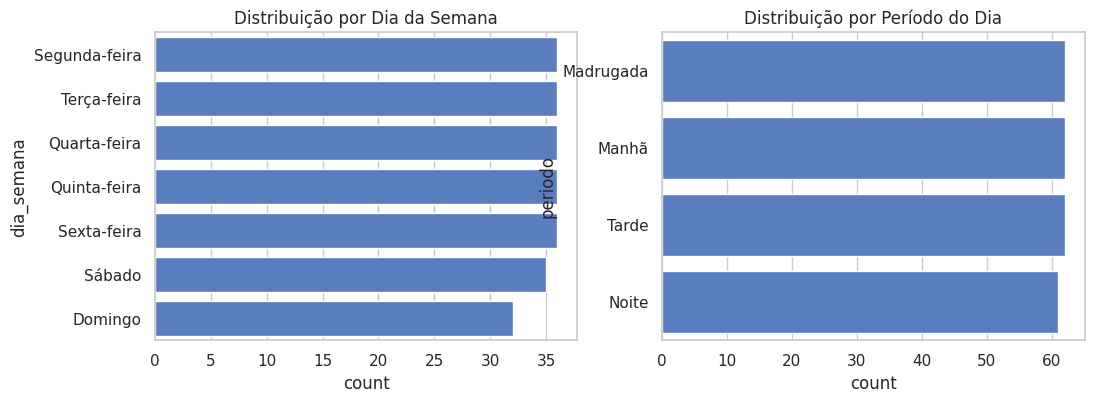

In [49]:
print("----------- DIMENSÃO DATA -----------")
print("="*60)
dim_data.info()
display(dim_data.head(10))
display(dim_data.describe(include='all'))

print("----------- Verificação -----------")
print("\n----------- Anos:", sorted(dim_data['ano'].unique()))
print("----------- Períodos:", dim_data['periodo'].unique())
print("----------- Dias da Semana:", dim_data['dia_semana'].unique())
print("----------- Períodos da Semana:", dim_data['periodo_semana'].unique())

print("----------- Visualização -----------")
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(y='dia_semana', data=dim_data, ax=ax[0])
ax[0].set_title("Distribuição por Dia da Semana")
sns.countplot(y='periodo', data=dim_data, ax=ax[1])
ax[1].set_title("Distribuição por Período do Dia")
plt.show()

#### Dimensão de Local (`dim_local`)

Criação da tabela de dimensão para 'uf', 'município', 'região', 'rodovia', 'rodovia_numero', 'quilômetro', 'latitude', 'longitude' e 'uso_solo'. Um `local_id` é gerado para cada localização única.

In [17]:
dim_local = df[['uf', 'municipio', 'regiao', 'rodovia', 'rodovia_numero',
                'quilometro', 'latitude', 'longitude', 'uso_solo']].drop_duplicates().copy()
dim_local['local_id'] = range(1, len(dim_local)+1)

📍 DIMENSÃO LOCAL
<class 'pandas.core.frame.DataFrame'>
Index: 9908 entries, 0 to 92262
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   uf              9908 non-null   object 
 1   municipio       9908 non-null   object 
 2   regiao          9908 non-null   object 
 3   rodovia         9880 non-null   object 
 4   rodovia_numero  9880 non-null   float64
 5   quilometro      9880 non-null   float64
 6   latitude        9908 non-null   float64
 7   longitude       9908 non-null   float64
 8   uso_solo        9908 non-null   object 
 9   local_id        9908 non-null   int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 851.5+ KB


,uf,municipio,regiao,rodovia,rodovia_numero,quilometro,latitude,longitude,uso_solo,local_id
0,RJ,TANGUA,Sudeste,BR-101,101.0,272.5,-22.729360,-42.701125,Urbano,1
1,GO,ANAPOLIS,Centro-Oeste,BR-153,153.0,424.6,-16.229185,-49.009797,Rural,2
3,ES,SERRA,Sudeste,BR-101,101.0,264.1,-20.172928,-40.267364,Urbano,3
4,SC,PENHA,Sul,BR-101,101.0,110.0,-26.834770,-48.706151,Rural,4
8,RS,NOVO HAMBURGO,Sul,BR-116,116.0,236.0,-29.669385,-51.143047,Urbano,5
12,PR,SAO JOSE DOS PINHAIS,Sul,BR-277,277.0,70.0,-25.541123,-49.061834,Rural,6
24,RS,CONDOR,Sul,BR-158,158.0,128.2,-28.111009,-53.424530,Rural,7
26,MS,TRES LAGOAS,Centro-Oeste,BR-262,262.0,4.3,-20.782074,-51.657050,Urbano,8
30,RJ,PARATY,Sudeste,BR-101,101.0,542.0,-23.041281,-44.595835,Rural,9
33,RO,PIMENTA BUENO,Norte,BR-364,364.0,197.0,-11.681961,-61.186219,Urbano,10


,uf,municipio,regiao,rodovia,rodovia_numero,quilometro,latitude,longitude,uso_solo,local_id
count,9908,9908,9908,9880,9880.000000,9880.00000,9908.000000,9908.000000,9908,9908.000000
unique,27,1404,5,103,NaN,NaN,NaN,NaN,2,NaN
top,MG,BRASILIA,Sul,BR-101,NaN,NaN,NaN,NaN,Rural,NaN
freq,1345,124,3016,1801,NaN,NaN,NaN,NaN,6064,NaN
mean,NaN,NaN,NaN,NaN,212.479555,263.22332,-18.939121,-46.440386,NaN,4954.500000
std,NaN,NaN,NaN,NaN,128.201897,228.91167,7.738195,6.130502,NaN,2860.337567
min,NaN,NaN,NaN,NaN,10.000000,0.00000,-33.607122,-70.557269,NaN,1.000000
25%,NaN,NaN,NaN,NaN,101.000000,76.60000,-25.306341,-50.372051,NaN,2477.750000
50%,NaN,NaN,NaN,NaN,163.000000,198.00000,-20.451049,-47.671945,NaN,4954.500000
75%,NaN,NaN,NaN,NaN,324.000000,413.75000,-12.800385,-42.185321,NaN,7431.250000



Top 10 Regiões:


,count
regiao,
Sul,3016
Sudeste,2963
Nordeste,2223
Centro-Oeste,1231
Norte,475



Top 10 Rodovias:


,count
rodovia,
BR-101,1801
BR-116,1393
BR-381,487
BR-040,392
BR-153,382
BR-163,345
BR-277,291
BR-364,287
BR-376,269



Coordenadas inválidas: 0


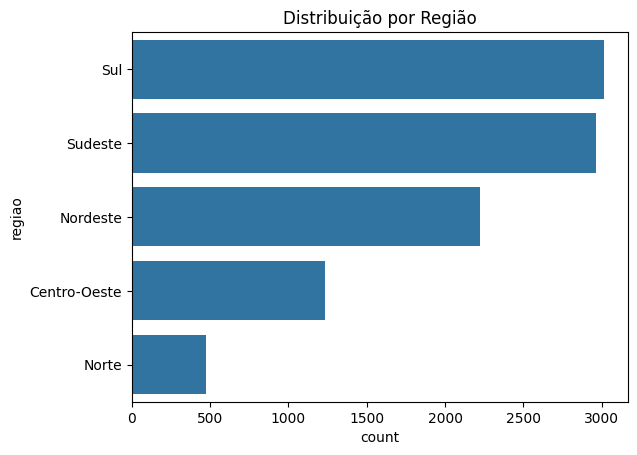

In [33]:
print("----------- DIMENSÃO LOCAL -----------")
print("="*60)
dim_local.info()
display(dim_local.head(10))
display(dim_local.describe(include='all'))

# Top regiões e rodovias
print("\n----------- Top 10 Regiões:")
display(dim_local['regiao'].value_counts().head(10))

print("\n----------- Top 10 Rodovias:")
display(dim_local['rodovia'].value_counts().head(10))

# Verificação de coordenadas
print("\n----------- Coordenadas inválidas:", dim_local[(dim_local['latitude']==0) | (dim_local['longitude']==0)].shape[0])

print("----------- Visualização  -----------")
sns.countplot(y='regiao', data=dim_local, order=dim_local['regiao'].value_counts().index)
plt.title("Distribuição por Região")
plt.show()


#### Dimensão de Veículo (`dim_veiculo`)

Criação da tabela de dimensão para 'veiculo_id', 'veiculo_tipo', 'veiculo_marca_modelo' e 'veiculo_ano_fabricacao'.

In [18]:
dim_veiculo = df[['veiculo_id', 'veiculo_tipo', 'veiculo_marca_modelo', 'veiculo_ano_fabricacao']].drop_duplicates()

🚗 DIMENSÃO VEÍCULO
<class 'pandas.core.frame.DataFrame'>
Index: 20594 entries, 0 to 92265
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   veiculo_id              20593 non-null  float64
 1   veiculo_tipo            20592 non-null  object 
 2   veiculo_marca_modelo    20592 non-null  object 
 3   veiculo_ano_fabricacao  19271 non-null  float64
dtypes: float64(2), object(2)
memory usage: 804.5+ KB


,veiculo_id,veiculo_tipo,veiculo_marca_modelo,veiculo_ano_fabricacao
0,1018215.0,Motocicleta,HONDA/CG 160 FAN,2023.0
1,1018226.0,Automóvel,VW/GOL 1.6 POWER,2009.0
3,1018251.0,Caminhonete,VW/SAVEIRO 1.6,2009.0
4,1018261.0,Camioneta,I/SSANGYONG ACTYON A23 4,2011.0
8,1018219.0,Automóvel,FIAT/PALIO FIRE ECONOMY,2010.0
12,1018220.0,Motocicleta,HONDA/CG 125 FAN KS,2009.0
24,1018283.0,Caminhonete,CHEVROLET/S10 LTZ DD2,2012.0
26,1018231.0,Automóvel,VW/GOL CL 1.8,1993.0
27,NaN,NaN,NaN,NaN
30,1018223.0,Automóvel,FORD/FIESTA FLEX,2013.0


,veiculo_id,veiculo_tipo,veiculo_marca_modelo,veiculo_ano_fabricacao
count,2.059300e+04,20592,20592,19271.000000
unique,NaN,22,3557,NaN
top,NaN,Automóvel,Não Informado/Não Informado,NaN
freq,NaN,7016,1082,NaN
mean,1.030534e+06,NaN,NaN,2013.108661
std,6.980522e+03,NaN,NaN,8.004476
min,1.018215e+06,NaN,NaN,1960.000000
25%,1.024527e+06,NaN,NaN,2009.000000
50%,1.030656e+06,NaN,NaN,2014.000000
75%,1.036545e+06,NaN,NaN,2020.000000



Tipos de veículos:


,count
veiculo_tipo,
Automóvel,7016
Motocicleta,4275
Semireboque,2268
Caminhão-trator,1805
Caminhonete,1661
Caminhão,1380
Motoneta,491
Camioneta,463
Utilitário,291



Top 10 marcas/modelos:


,count
veiculo_marca_modelo,
Não Informado/Não Informado,1082
HONDA/CG 160 FAN,366
SR/RANDON SR CA,291
HONDA/CG 160 START,286
VOLVO/FH 540 6X4T,168
HONDA/NXR160 BROS ESDD,161
HONDA/CG 160 TITAN,159
HONDA/CG 125 FAN KS,149
VW/GOL 1.0,148


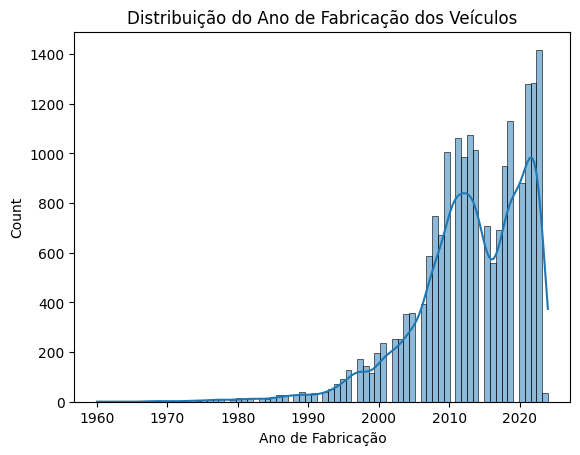

In [34]:
print("----------- DIMENSÃO VEÍCULO-----------")
print("="*60)
dim_veiculo.info()
display(dim_veiculo.head(10))
display(dim_veiculo.describe(include='all'))

# Verificar tipos e marcas
print("\n----------- Tipos de veículos:")
display(dim_veiculo['veiculo_tipo'].value_counts())

print("\n----------- Top 10 marcas/modelos:")
display(dim_veiculo['veiculo_marca_modelo'].value_counts().head(10))

print("----------- Visualização -----------")
sns.histplot(dim_veiculo['veiculo_ano_fabricacao'].dropna(), kde=True)
plt.title("Distribuição do Ano de Fabricação dos Veículos")
plt.xlabel("Ano de Fabricação")
plt.show()

#### Dimensão de Envolvido (`dim_envolvido`)

Criação da tabela de dimensão para 'id_envolvido', 'envolvido_sexo', 'envolvido_tipo', 'estado_fisico', 'faixa_etaria_ano', 'faixa_etaria_classe' e 'envolvido_idade'.

In [19]:
dim_envolvido = df[['id_envolvido', 'envolvido_sexo', 'envolvido_tipo',
                    'estado_fisico', 'faixa_etaria_ano', 'faixa_etaria_classe',
                    'envolvido_idade']].drop_duplicates()

👤 DIMENSÃO ENVOLVIDO
<class 'pandas.core.frame.DataFrame'>
Index: 27430 entries, 0 to 92265
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_envolvido         27429 non-null  float64
 1   envolvido_sexo       27429 non-null  object 
 2   envolvido_tipo       27429 non-null  object 
 3   estado_fisico        27428 non-null  object 
 4   faixa_etaria_ano     24973 non-null  object 
 5   faixa_etaria_classe  24973 non-null  object 
 6   envolvido_idade      24951 non-null  float64
dtypes: float64(2), object(5)
memory usage: 1.7+ MB


,id_envolvido,envolvido_sexo,envolvido_tipo,estado_fisico,faixa_etaria_ano,faixa_etaria_classe,envolvido_idade
0,1268971.0,Masculino,Condutor,Óbito,20-29,Adulto,26.0
1,1268985.0,Feminino,Condutor,Ileso,30-39,Adulto,34.0
3,1269020.0,Masculino,Condutor,Ileso,50-59,Adulto,55.0
4,1269028.0,Masculino,Condutor,Ileso,50-59,Adulto,53.0
5,1269045.0,Feminino,Passageiro,Lesões Leves,30-39,Adulto,33.0
8,1268998.0,Feminino,Passageiro,Ileso,0-9,Criança,6.0
9,1268999.0,Masculino,Passageiro,Ileso,0-9,Criança,9.0
10,1269000.0,Feminino,Passageiro,Ileso,10-19,Adolescente,13.0
11,1268976.0,Masculino,Condutor,Ileso,40-49,Adulto,42.0
12,1271043.0,Feminino,Passageiro,Lesões Leves,30-39,Adulto,32.0


,id_envolvido,envolvido_sexo,envolvido_tipo,estado_fisico,faixa_etaria_ano,faixa_etaria_classe,envolvido_idade
count,2.742900e+04,27429,27429,27428,24973,24973,24951.000000
unique,NaN,4,6,5,11,4,NaN
top,NaN,Masculino,Condutor,Ileso,30-39,Adulto,NaN
freq,NaN,18840,18084,11756,5960,20667,NaN
mean,1.285545e+06,NaN,NaN,NaN,NaN,NaN,39.494850
std,9.306000e+03,NaN,NaN,NaN,NaN,NaN,15.732492
min,1.268971e+06,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1.277591e+06,NaN,NaN,NaN,NaN,NaN,28.000000
50%,1.285657e+06,NaN,NaN,NaN,NaN,NaN,38.000000
75%,1.293525e+06,NaN,NaN,NaN,NaN,NaN,50.000000


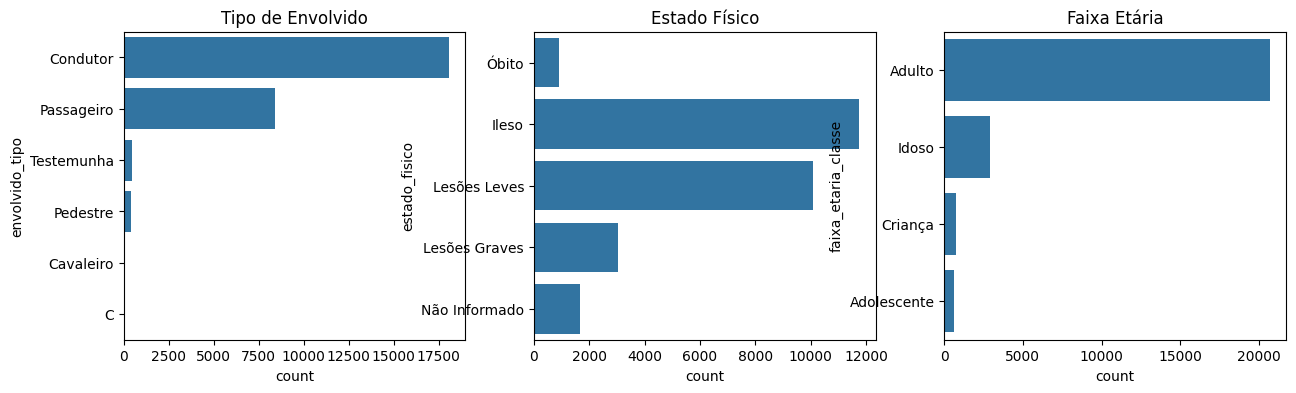

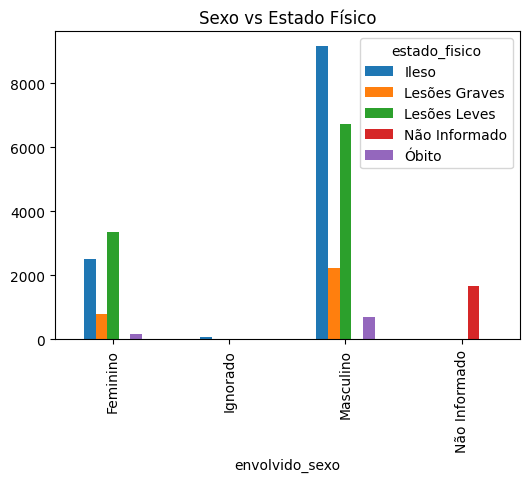

In [35]:
print("----------- DIMENSÃO ENVOLVIDO -----------")
print("="*60)
dim_envolvido.info()
display(dim_envolvido.head(10))
display(dim_envolvido.describe(include='all'))

# Distribuições principais
fig, ax = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(y='envolvido_tipo', data=dim_envolvido, ax=ax[0])
ax[0].set_title("Tipo de Envolvido")

sns.countplot(y='estado_fisico', data=dim_envolvido, ax=ax[1])
ax[1].set_title("Estado Físico")

sns.countplot(y='faixa_etaria_classe', data=dim_envolvido, order=dim_envolvido['faixa_etaria_classe'].value_counts().index, ax=ax[2])
ax[2].set_title("Faixa Etária")
plt.show()

print("----------- Visualização -----------")
pd.crosstab(dim_envolvido['envolvido_sexo'], dim_envolvido['estado_fisico']).plot(kind='bar', figsize=(6,4))
plt.title("Sexo vs Estado Físico")
plt.show()


#### Dimensão de Causa (`dim_causa`)

Criação da tabela de dimensão para 'sinistro_tipo', 'sinistro_causa' e 'sinistro_causa_principal'. Um `causa_id` é gerado para cada causa única.

In [20]:
dim_causa = df[['sinistro_tipo', 'sinistro_causa', 'sinistro_causa_principal']].drop_duplicates().copy()
dim_causa['causa_id'] = range(1, len(dim_causa)+1)

⚠️ DIMENSÃO CAUSA
<class 'pandas.core.frame.DataFrame'>
Index: 1283 entries, 0 to 92040
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   sinistro_tipo             1283 non-null   object
 1   sinistro_causa            1283 non-null   object
 2   sinistro_causa_principal  1283 non-null   object
 3   causa_id                  1283 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ KB


,sinistro_tipo,sinistro_causa,sinistro_causa_principal,causa_id
0,Colisão com objeto,Reação tardia ou ineficiente do condutor,Sim,1
1,Colisão com objeto,Animais na Pista,Não,2
2,Colisão com objeto,Velocidade Incompatível,Sim,3
4,Saída de leito carroçável,Reação tardia ou ineficiente do condutor,Não,4
6,Saída de leito carroçável,Acumulo de água sobre o pavimento,Sim,5
8,Colisão com objeto,Ausência de reação do condutor,Sim,6
12,Queda de ocupante de veículo,Reação tardia ou ineficiente do condutor,Não,7
14,Queda de ocupante de veículo,Condutor Dormindo,Não,8
16,Queda de ocupante de veículo,Ausência de reação do condutor,Sim,9
18,Tombamento,Reação tardia ou ineficiente do condutor,Não,10


,sinistro_tipo,sinistro_causa,sinistro_causa_principal,causa_id
count,1283,1283,1283,1283.000000
unique,16,70,2,NaN
top,Tombamento,Reação tardia ou ineficiente do condutor,Não,NaN
freq,121,32,686,NaN
mean,NaN,NaN,NaN,642.000000
std,NaN,NaN,NaN,370.514507
min,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,321.500000
50%,NaN,NaN,NaN,642.000000
75%,NaN,NaN,NaN,962.500000


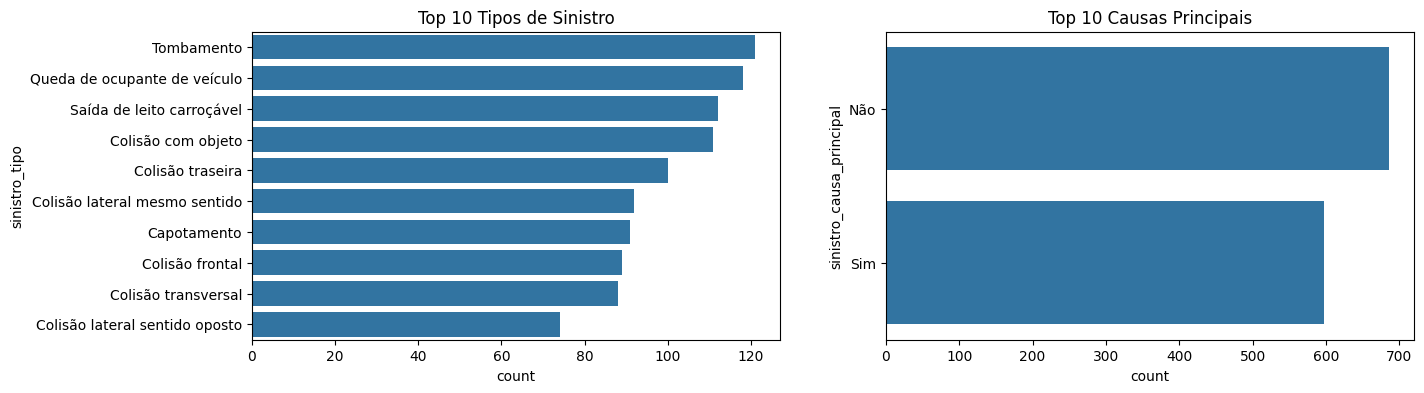

In [36]:
print("----------- DIMENSÃO CAUSA -----------")
print("="*60)
dim_causa.info()
display(dim_causa.head(10))
display(dim_causa.describe(include='all'))

# Tipos e causas
print("----------- Visualização -----------")
fig, ax = plt.subplots(1, 2, figsize=(15,4))
sns.countplot(y='sinistro_tipo', data=dim_causa, order=dim_causa['sinistro_tipo'].value_counts().index[:10], ax=ax[0])
ax[0].set_title("Top 10 Tipos de Sinistro")

sns.countplot(y='sinistro_causa_principal', data=dim_causa, order=dim_causa['sinistro_causa_principal'].value_counts().index[:10], ax=ax[1])
ax[1].set_title("Top 10 Causas Principais")
plt.show()


### 4. Construção da Tabela Fato (`fato_sinistro`)

Após a criação das tabelas de dimensão, unimos (`merge`) os dados do DataFrame original com as dimensões correspondentes para construir a tabela fato `fato_sinistro`. Esta tabela contém as chaves das dimensões e as métricas relacionadas aos sinistros, como número de ilesos, feridos e mortos, além da gravidade.

In [22]:
fato_sinistro = df.merge(dim_data, on='data', how='left') \
                  .merge(dim_local, on=['uf','municipio','rodovia','quilometro'], how='left') \
                  .merge(dim_veiculo, on='veiculo_id', how='left') \
                  .merge(dim_envolvido, on='id_envolvido', how='left') \
                  .merge(dim_causa, on=['sinistro_tipo','sinistro_causa','sinistro_causa_principal'], how='left')

fato_sinistro = fato_sinistro[['sinistro_id', 'data_id', 'local_id', 'veiculo_id', 'id_envolvido', 'causa_id',
                               'ilesos', 'feridos_leves', 'feridos_graves', 'feridos', 'mortos', 'gravidade']]

💥 FATO SINISTRO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444907 entries, 0 to 444906
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   sinistro_id     444907 non-null  int64  
 1   data_id         444907 non-null  int64  
 2   local_id        444907 non-null  int64  
 3   veiculo_id      431507 non-null  float64
 4   id_envolvido    407610 non-null  float64
 5   causa_id        444907 non-null  int64  
 6   ilesos          407607 non-null  float64
 7   feridos_leves   407607 non-null  float64
 8   feridos_graves  407607 non-null  float64
 9   feridos         444904 non-null  float64
 10  mortos          407607 non-null  float64
 11  gravidade       444904 non-null  object 
dtypes: float64(7), int64(4), object(1)
memory usage: 40.7+ MB


,sinistro_id,data_id,local_id,veiculo_id,id_envolvido,causa_id,ilesos,feridos_leves,feridos_graves,feridos,mortos,gravidade
0,571772,20240101,1,1018215.0,1268971.0,1,0.0,0.0,0.0,0.0,1.0,Com morto
1,571772,20240101,1,1018215.0,1268971.0,1,0.0,0.0,0.0,0.0,1.0,Com morto
2,571772,20240101,1,1018215.0,1268971.0,1,0.0,0.0,0.0,0.0,1.0,Com morto
3,571772,20240101,1,1018215.0,1268971.0,1,0.0,0.0,0.0,0.0,1.0,Com morto
4,571774,20240101,2,1018226.0,1268985.0,2,1.0,0.0,0.0,0.0,0.0,Sem vítima
5,571774,20240101,2,1018226.0,1268985.0,2,1.0,0.0,0.0,0.0,0.0,Sem vítima
6,571774,20240101,2,1018226.0,1268985.0,2,1.0,0.0,0.0,0.0,0.0,Sem vítima
7,571774,20240101,2,1018226.0,1268985.0,2,1.0,0.0,0.0,0.0,0.0,Sem vítima
8,571774,20240101,2,1018226.0,1268985.0,3,1.0,0.0,0.0,0.0,0.0,Sem vítima
9,571774,20240101,2,1018226.0,1268985.0,3,1.0,0.0,0.0,0.0,0.0,Sem vítima


,sinistro_id,data_id,local_id,veiculo_id,id_envolvido,causa_id,ilesos,feridos_leves,feridos_graves,feridos,mortos
count,444907.000000,4.449070e+05,444907.000000,4.315070e+05,4.076100e+05,444907.000000,407607.000000,407607.000000,407607.000000,444904.000000,407607.000000
mean,578106.779835,2.024016e+07,4768.644852,1.030252e+06,1.285620e+06,220.482919,0.409350,0.355458,0.126178,0.441259,0.046206
std,3591.311580,5.280762e+01,2828.463782,6.869332e+03,9.115000e+03,238.338626,0.491715,0.478652,0.332050,0.496538,0.209932
min,571772.000000,2.024010e+07,1.000000,1.018215e+06,1.268971e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,575054.000000,2.024012e+07,2296.000000,1.024361e+06,1.278006e+06,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,578190.000000,2.024013e+07,4741.000000,1.030449e+06,1.285972e+06,143.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,581155.000000,2.024021e+07,7206.000000,1.035984e+06,1.293479e+06,292.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,584471.000000,2.024030e+07,9908.000000,1.048382e+06,1.309895e+06,1283.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Total de sinistros: 444907
Total de feridos: 196318.0
Total de mortos: 18834.0


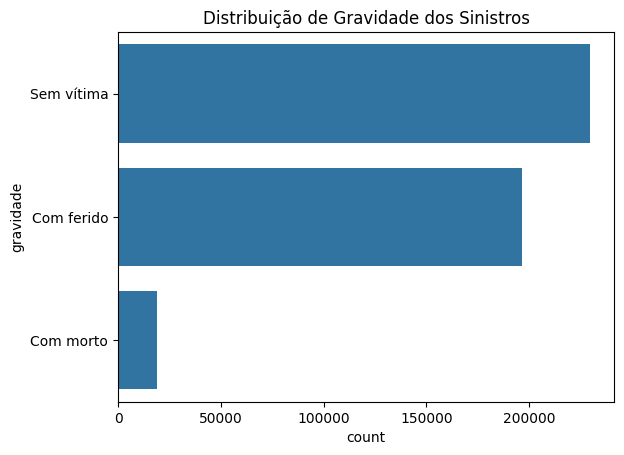

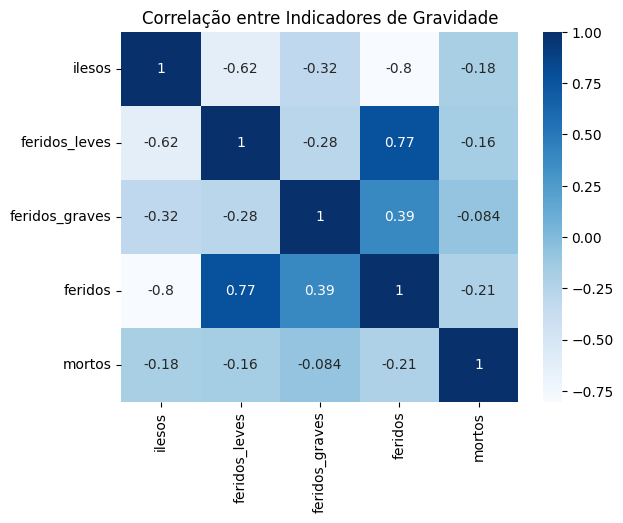

In [37]:
print("💥 FATO SINISTRO")
print("="*60)
fato_sinistro.info()
display(fato_sinistro.head(10))
display(fato_sinistro.describe())

# Quantidade total de vítimas
print("\n----------- Total de sinistros:", len(fato_sinistro))
print("----------- Total de feridos:", fato_sinistro['feridos'].sum())
print("----------- Total de mortos:", fato_sinistro['mortos'].sum())

# Gravidade dos sinistros
print("----------- Visualização -----------")
sns.countplot(y='gravidade', data=fato_sinistro, order=fato_sinistro['gravidade'].value_counts().index)
plt.title("Distribuição de Gravidade dos Sinistros")
plt.show()

# Correlação entre variáveis numéricas
corr = fato_sinistro[['ilesos','feridos_leves','feridos_graves','feridos','mortos']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlação entre Indicadores de Gravidade")
plt.show()


### 5. Análises e Visualizações

Nesta seção, realizamos análises e visualizações para extrair insights sobre os dados de sinistros, explorando relações entre diferentes variáveis e a gravidade dos eventos.

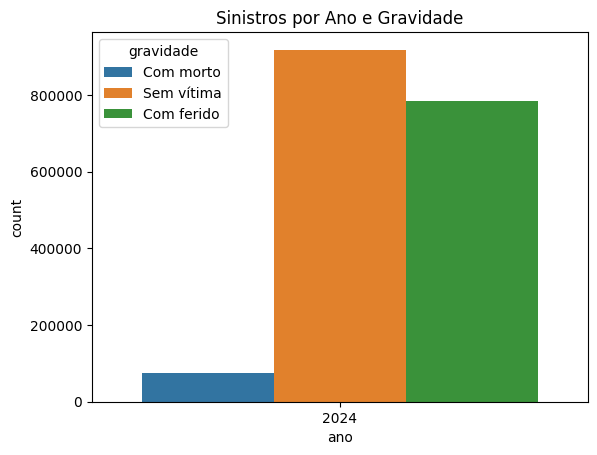

In [38]:
# Sinistros por ano e gravidade
merged = fato_sinistro.merge(dim_data, on='data_id')
sns.countplot(x='ano', hue='gravidade', data=merged)
plt.title('Sinistros por Ano e Gravidade')
plt.show()

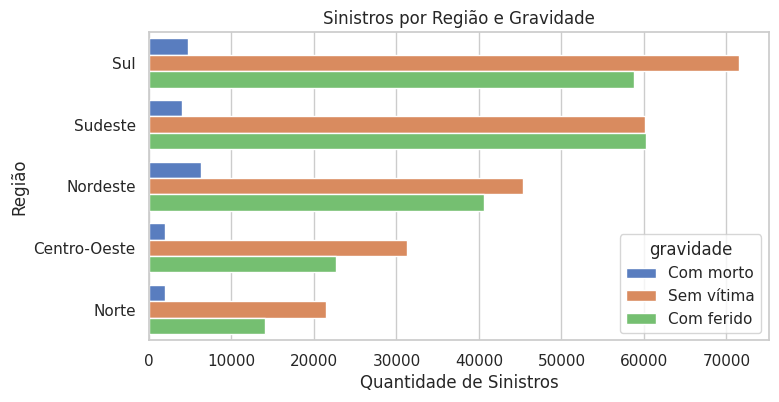

In [40]:
merged = fato_sinistro.merge(dim_local[['local_id', 'regiao']], on='local_id', how='left')

sns.countplot(y='regiao', hue='gravidade', data=merged, order=merged['regiao'].value_counts().index)
plt.title('Sinistros por Região e Gravidade')
plt.xlabel('Quantidade de Sinistros')
plt.ylabel('Região')
plt.show()

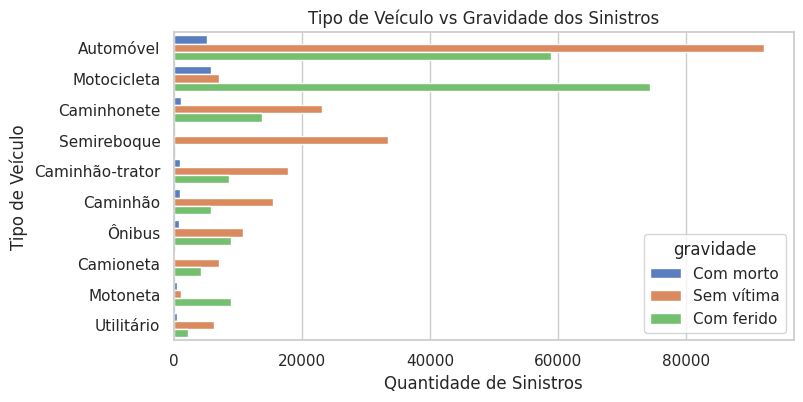

In [41]:
merged = fato_sinistro.merge(dim_veiculo[['veiculo_id', 'veiculo_tipo']], on='veiculo_id', how='left')

sns.countplot(y='veiculo_tipo', hue='gravidade', data=merged,
              order=merged['veiculo_tipo'].value_counts().index[:10])
plt.title('Tipo de Veículo vs Gravidade dos Sinistros')
plt.xlabel('Quantidade de Sinistros')
plt.ylabel('Tipo de Veículo')
plt.show()

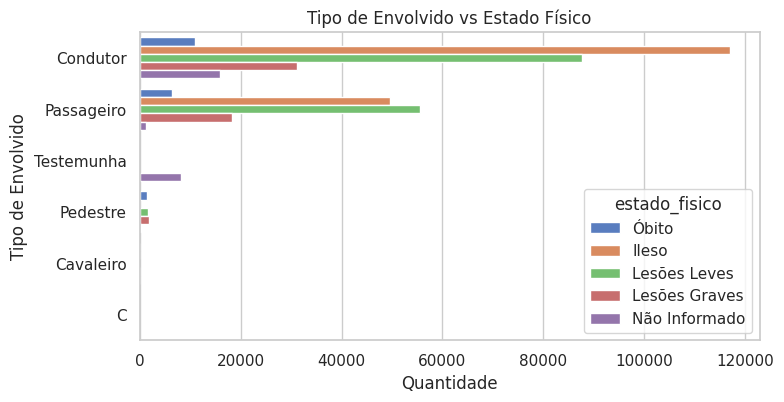

In [43]:
merged = fato_sinistro.merge(dim_envolvido[['id_envolvido', 'envolvido_tipo', 'estado_fisico']],
                             on='id_envolvido', how='left')

sns.countplot(y='envolvido_tipo', hue='estado_fisico', data=merged,
              order=merged['envolvido_tipo'].value_counts().index)
plt.title('Tipo de Envolvido vs Estado Físico')
plt.xlabel('Quantidade')
plt.ylabel('Tipo de Envolvido')
plt.show()

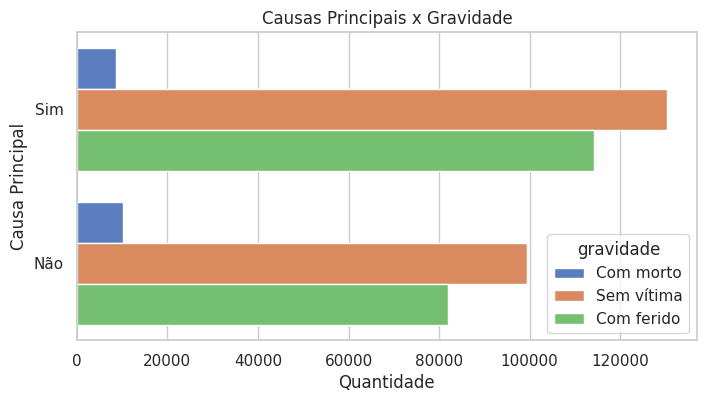

In [44]:
merged = fato_sinistro.merge(dim_causa[['causa_id', 'sinistro_causa_principal']],
                             on='causa_id', how='left')

top_causas = merged['sinistro_causa_principal'].value_counts().index[:10]

sns.countplot(y='sinistro_causa_principal', hue='gravidade', data=merged,
              order=top_causas)
plt.title('Causas Principais x Gravidade')
plt.xlabel('Quantidade')
plt.ylabel('Causa Principal')
plt.show()

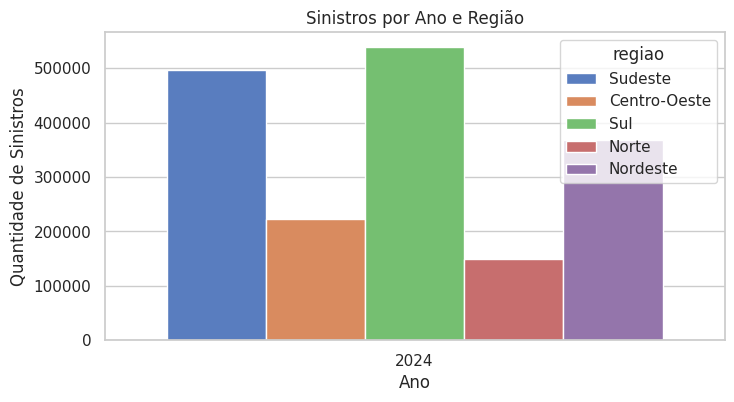

In [45]:
merged = (fato_sinistro
          .merge(dim_data[['data_id', 'ano']], on='data_id', how='left')
          .merge(dim_local[['local_id', 'regiao']], on='local_id', how='left'))

sns.countplot(x='ano', hue='regiao', data=merged)
plt.title('Sinistros por Ano e Região')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Sinistros')
plt.show()


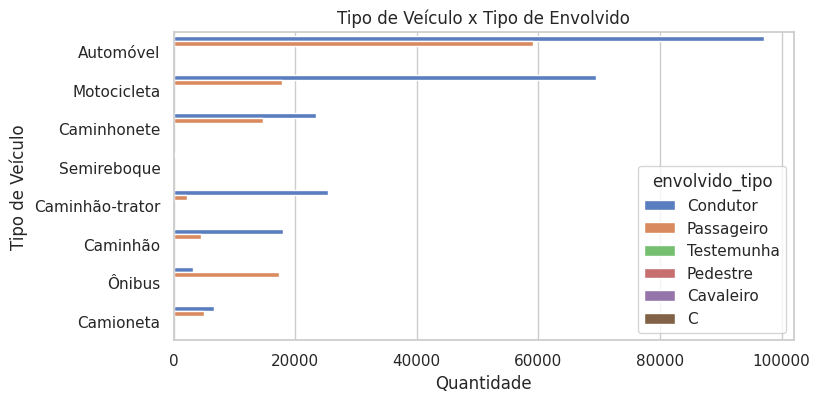

In [47]:
merged = (fato_sinistro
          .merge(dim_veiculo[['veiculo_id', 'veiculo_tipo']], on='veiculo_id', how='left')
          .merge(dim_envolvido[['id_envolvido', 'envolvido_tipo']], on='id_envolvido', how='left'))

sns.countplot(y='veiculo_tipo', hue='envolvido_tipo', data=merged,
              order=merged['veiculo_tipo'].value_counts().index[:8])
plt.title('Tipo de Veículo x Tipo de Envolvido')
plt.xlabel('Quantidade')
plt.ylabel('Tipo de Veículo')
plt.show()

In [48]:
merged_all = (fato_sinistro
    .merge(dim_data[['data_id', 'ano', 'periodo']], on='data_id', how='left')
    .merge(dim_local[['local_id', 'regiao', 'municipio']], on='local_id', how='left')
    .merge(dim_veiculo[['veiculo_id', 'veiculo_tipo']], on='veiculo_id', how='left')
    .merge(dim_envolvido[['id_envolvido', 'envolvido_tipo', 'estado_fisico']], on='id_envolvido', how='left')
    .merge(dim_causa[['causa_id', 'sinistro_causa_principal']], on='causa_id', how='left')
)

merged_all.sample(5)

,sinistro_id,data_id,local_id,veiculo_id,id_envolvido,causa_id,ilesos,feridos_leves,feridos_graves,feridos,mortos,gravidade,ano,periodo,regiao,municipio,veiculo_tipo,envolvido_tipo,estado_fisico,sinistro_causa_principal
538056,575691,20240119,3117,1.03e+06,1.28e+06,58,1.0,0.0,0.0,0.0,0.0,Sem vítima,2024,Madrugada,Sul,REBOUCAS,Caminhão,Condutor,Ileso,Sim
645865,576477,20240122,3743,1.03e+06,1.28e+06,267,0.0,0.0,0.0,0.0,1.0,Com morto,2024,Manhã,Sul,CAXIAS DO SUL,Caminhão,Passageiro,Óbito,Sim
1475128,582018,20240219,8074,1.04e+06,1.30e+06,65,0.0,1.0,0.0,1.0,0.0,Com ferido,2024,Madrugada,Sudeste,PARACATU,Automóvel,Condutor,Lesões Leves,Sim
949492,578662,20240123,5422,1.03e+06,1.29e+06,897,1.0,0.0,0.0,0.0,0.0,Sem vítima,2024,Madrugada,Centro-Oeste,ALTO ARAGUAIA,Caminhonete,Condutor,Ileso,Sim
458461,575155,20240116,2710,1.02e+06,1.28e+06,173,0.0,1.0,0.0,1.0,0.0,Com ferido,2024,Manhã,Sudeste,CAJATI,Motocicleta,Condutor,Lesões Leves,Sim


### 6. Exportação dos Dados

As tabelas de dimensão e a tabela fato são salvas em arquivos CSV para uso posterior, como em ferramentas de Business Intelligence ou outras análises.

In [23]:
dim_data.to_csv('dim_data.csv', index=False)
dim_local.to_csv('dim_local.csv', index=False)
dim_veiculo.to_csv('dim_veiculo.csv', index=False)
dim_envolvido.to_csv('dim_envolvido.csv', index=False)
dim_causa.to_csv('dim_causa.csv', index=False)
fato_sinistro.to_csv('fato_sinistro.csv', index=False)